In [84]:
# === Basic Libraries ===
import os                     
import time                   
import numpy as np            
import pandas as pd           
import matplotlib.pyplot as plt  
import seaborn as sns         
from scipy.signal import correlate

# === Statistical Functions ===
from scipy.stats import kurtosis, skew  

# === Machine Learning Tools
from sklearn.model_selection import StratifiedKFold  
from sklearn.preprocessing import LabelEncoder, StandardScaler  
from sklearn.pipeline import Pipeline  

# === Model Evaluation Metrics ===
from sklearn.metrics import (
    accuracy_score,                  
    precision_score,                 
    recall_score,                    
    f1_score,                       
    classification_report,          
    precision_recall_fscore_support,
    confusion_matrix,               
    ConfusionMatrixDisplay          
)

# === Classification Models (Scikit-learn) ===
from sklearn.linear_model import LogisticRegression           
from sklearn.ensemble import RandomForestClassifier           
from sklearn.ensemble import GradientBoostingClassifier      
from sklearn.ensemble import AdaBoostClassifier               
from sklearn.svm import SVC                                   
from sklearn.neighbors import KNeighborsClassifier            
from sklearn.tree import DecisionTreeClassifier               
from sklearn.naive_bayes import GaussianNB                    
from sklearn.neural_network import MLPClassifier              

# === Optional: Gradient Boosting Alternatives ===
from xgboost import XGBClassifier     
from lightgbm import LGBMClassifier   

# === Save/Load Models ===
import joblib     

# --- Deep Learning Version: 1D CNN and LSTM for PM_980 DATASET ---
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, LSTM, Input
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from tensorflow.keras.models import load_model

In [40]:
from datetime import datetime
print(datetime.now().strftime("%Y-%m-%d"))
print("Cavit Eren YILDIZ -- 201805001")

2025-06-04
Cavit Eren YILDIZ -- 201805001


In [42]:
def extract_label(filename):
    """
    Extracts the class label from the filename.
    Expected format: something_label_environment_noise.csv
    """
    parts = filename.replace('.csv', '').split('_')
    label_part = parts[2] if len(parts) > 2 else 'unknown'
    
    if label_part.startswith('healthy'):
        return 'healthy'
    else:
        return label_part.lower()


In [44]:
def extract_features_from_df(df, label, environment, noise):
    """
    Computes time-domain statistical features from each signal column in the DataFrame.
    Also appends label, environment, and noise values at the end.
    """
    features = []
    
    for col in feature_columns:
        if col in df.columns:
            signal = df[col].values
            features.extend([
                np.mean(signal), np.std(signal), np.min(signal),
                np.max(signal), np.median(signal),
                kurtosis(signal), skew(signal)
            ])
        else:
            # If column missing, fill with NaNs and warn
            features.extend([np.nan] * len(stat_funcs))
            print(f"Warning: '{col}' column is missing.")
    
    features.extend([label, environment, noise])
    return features


In [46]:
def extract_features_from_file(file_path, filename):
    """
    Splits a raw CSV file into train and test sets (80/20),
    and extracts features for both.
    """
    df = pd.read_csv(file_path)
    df.columns = df.columns.str.strip()  # Clean whitespace

    # Split data by 80/20
    split_index = int(len(df) * 0.8)
    train_df = df.iloc[:split_index]
    test_df = df.iloc[split_index:]

    # Extract metadata
    label = extract_label(filename)
    parts = filename.replace('.csv', '').split('_')
    environment = parts[3] if len(parts) > 3 else 'unknown'
    noise = parts[4] if len(parts) > 4 else 'unknown'

    # Extract time-domain features for both sets
    train_features = extract_features_from_df(train_df, label, environment, noise)
    test_features = extract_features_from_df(test_df, label, environment, noise)
    
    return train_features, test_features


In [48]:
def process_folder(folder_path):
    """
    Iterates over all CSV files in the given folder,
    extracts features, and saves two CSVs:
    - train_features.csv
    - test_features.csv
    """
    train_feature_rows = []
    test_feature_rows = []

    for filename in os.listdir(folder_path):
        if filename.endswith('.csv'):
            file_path = os.path.join(folder_path, filename)
            train_feats, test_feats = extract_features_from_file(file_path, filename)
            train_feature_rows.append(train_feats)
            test_feature_rows.append(test_feats)

    # Create DataFrames and save to CSV
    train_df = pd.DataFrame(train_feature_rows, columns=header)
    test_df = pd.DataFrame(test_feature_rows, columns=header)

    train_df.to_csv(os.path.join(folder_path, 'train_features.csv'), index=False)
    test_df.to_csv(os.path.join(folder_path, 'test_features.csv'), index=False)


In [50]:
folder_path = "PM980"
feature_columns = ['Voice', 'Acceleration X', 'Acceleration Y', 'Acceleration Z',
                   'Gyro X', 'Gyro Y', 'Gyro Z', 'Temperature']
stat_funcs = ['mean', 'std', 'min', 'max', 'median', 'kurtosis', 'skew']
header = [f"{func}_{col}" for col in feature_columns for func in stat_funcs] + ['label', 'environment', 'noise']

# Now run the processing
process_folder(folder_path)

In [51]:
# Load the CSV file
df = pd.read_csv('PM980/train_features.csv')

# Create LabelEncoders
le_env = LabelEncoder()
le_noise = LabelEncoder()
le_label = LabelEncoder()  # encoder for label column

# Encode the 'environment' and 'noise' columns
df['environment'] = le_env.fit_transform(df['environment'])
df['noise'] = le_noise.fit_transform(df['noise'])

# Encode the 'label' column
df['label'] = le_label.fit_transform(df['label'])

"""# You can drop the original columns or keep them
df = df.drop(columns=['environment', 'noise', 'label'])"""

# Save as a new CSV file
df.to_csv('PM980/train_features_encoded.csv', index=False)

print("Environment classes:", list(le_env.classes_))
print("Noise classes:", list(le_noise.classes_))
print("Label classes:", list(le_label.classes_))

Environment classes: ['indoor', 'outdoor']
Noise classes: ['clear', 'noisy']
Label classes: ['healthy', 'notchlong', 'notchshort', 'scracth', 'singlecutlong', 'singlecutshort', 'twocutlong', 'twocutshort', 'warped']


In [52]:
# Load the CSV file
df = pd.read_csv('PM980/test_features.csv')

# Create LabelEncoders
le_env = LabelEncoder()
le_noise = LabelEncoder()
le_label = LabelEncoder()  # encoder for the label column

# Encode the 'environment' and 'noise' columns
df['environment'] = le_env.fit_transform(df['environment'])
df['noise'] = le_noise.fit_transform(df['noise'])

# Encode the 'label' column
df['label'] = le_label.fit_transform(df['label'])

# Save as a new CSV file
df.to_csv('PM980/test_features_encoded.csv', index=False)

print("Environment classes:", list(le_env.classes_))
print("Noise classes:", list(le_noise.classes_))
print("Label classes:", list(le_label.classes_))

Environment classes: ['indoor', 'outdoor']
Noise classes: ['clear', 'noisy']
Label classes: ['healthy', 'notchlong', 'notchshort', 'scracth', 'singlecutlong', 'singlecutshort', 'twocutlong', 'twocutshort', 'warped']


In [53]:
# 1. Load encoded training data
df = pd.read_csv('PM980/train_features_encoded.csv')
print(df.head())

    mean_Voice    std_Voice  min_Voice  max_Voice  median_Voice  \
0  1800.619266  1215.706133        0.0     2929.0        2263.5   
1  1453.981651  1058.451660        0.0     2928.0        1595.5   
2  1424.949541  1146.538869        0.0     2931.0        1430.5   
3  1569.227679  1052.292992        0.0     2929.0        1565.5   
4  1468.901376  1019.121513        0.0     2928.0        1525.0   

   kurtosis_Voice  skew_Voice  mean_Acceleration X  std_Acceleration X  \
0       -1.426824   -0.528386            -0.309266            1.523689   
1       -1.397547   -0.068262            -0.298394            1.034502   
2       -1.557806    0.098213            -0.003440            5.922319   
3       -1.384189   -0.067923            -0.122857            1.419987   
4       -1.340763   -0.036620            -0.316491            1.712446   

   min_Acceleration X  ...  mean_Temperature  std_Temperature  \
0               -6.03  ...         27.169817         0.012524   
1               -2.35 

In [54]:
X = df.drop(columns=['label','environment','noise'])  # Features
y = df['label']                 # Target labels

In [55]:
le = LabelEncoder()
y_enc = le.fit_transform(y)
# 2. Define classification models
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=13),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=13),
    'DecisionTree': DecisionTreeClassifier(random_state=13),
    'GradientBoosting': GradientBoostingClassifier(random_state=13),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=13)
}

# 3. Setup Stratified K-Fold cross-validation
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=13)

# 4. Initialize structure to store results
results = {name: {'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'train_time': [], 'test_time': []} 
           for name in models.keys()}

# 5. Train and evaluate each model using cross-validation
for model_name, model in models.items():
    print(f"Training model: {model_name}")
    
    for train_idx, test_idx in skf.split(X, y_enc):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y_enc[train_idx], y_enc[test_idx]
        
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', model)
        ])
        
        start_train = time.time()
        pipeline.fit(X_train, y_train)
        end_train = time.time()
        
        start_test = time.time()
        y_pred = pipeline.predict(X_test)
        end_test = time.time()
        
        acc = accuracy_score(y_test, y_pred)
        precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average=None, zero_division=0)
        
        # Store the scores and timings
        results[model_name]['accuracy'].append(acc)
        results[model_name]['precision'].append(precision)
        results[model_name]['recall'].append(recall)
        results[model_name]['f1'].append(f1)
        results[model_name]['train_time'].append(end_train - start_train)
        results[model_name]['test_time'].append(end_test - start_test)

# 6. Summarize model performance
print("\nModel Performances (mean ± std):\n")
for model_name, res in results.items():
    print(f"Model: {model_name}")
    print(f"Accuracy: {np.mean(res['accuracy']):.4f} ± {np.std(res['accuracy']):.4f}")
    print(f"Train time (s): {np.mean(res['train_time']):.4f} ± {np.std(res['train_time']):.4f}")
    print(f"Test time (s): {np.mean(res['test_time']):.4f} ± {np.std(res['test_time']):.4f}")
    
    precision_avg = np.mean(res['precision'], axis=0)
    recall_avg = np.mean(res['recall'], axis=0)
    f1_avg = np.mean(res['f1'], axis=0)
    
    for i, cls in enumerate(le.classes_):
        print(f"  Class '{cls}': Precision={precision_avg[i]:.3f}, Recall={recall_avg[i]:.3f}, F1={f1_avg[i]:.3f}")
    print("-" * 40)

# 7. Select the best model based on average accuracy
best_model_name = max(results, key=lambda k: np.mean(results[k]['accuracy']))
print(f"\nBest model: {best_model_name}")


# 8. Train the best model
best_model = models[best_model_name]
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', best_model)
])
pipeline.fit(X, y_enc)
y_pred = pipeline.predict(X)

Training model: LogisticRegression
Training model: RandomForest
Training model: DecisionTree
Training model: GradientBoosting
Training model: XGBoost

Model Performances (mean ± std):

Model: LogisticRegression
Accuracy: 0.6417 ± 0.0358
Train time (s): 0.0214 ± 0.0076
Test time (s): 0.0006 ± 0.0005
  Class '0': Precision=0.731, Recall=0.942, F1=0.821
  Class '1': Precision=0.420, Recall=0.400, F1=0.382
  Class '2': Precision=0.240, Recall=0.167, F1=0.180
  Class '3': Precision=0.550, Recall=0.267, F1=0.337
  Class '4': Precision=0.580, Recall=0.533, F1=0.527
  Class '5': Precision=0.707, Recall=0.400, F1=0.477
  Class '6': Precision=0.458, Recall=0.500, F1=0.464
  Class '7': Precision=0.383, Recall=0.333, F1=0.327
  Class '8': Precision=0.300, Recall=0.133, F1=0.180
----------------------------------------
Model: RandomForest
Accuracy: 0.8333 ± 0.0484
Train time (s): 0.2705 ± 0.0096
Test time (s): 0.0030 ± 0.0005
  Class '0': Precision=0.827, Recall=0.983, F1=0.898
  Class '1': Precisi

In [56]:
# Select the best model (already determined in your code)
best_model = models[best_model_name]

# Create a pipeline with scaling and the selected model
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', best_model)
])

# Train the model on the entire training dataset
pipeline.fit(X, y_enc)

# Save the trained model to a file (e.g., 'best_model.pkl')
joblib.dump(pipeline, 'best_model.pkl')
print("Model has been successfully saved.")


Model has been successfully saved.


In [57]:
# 1. Load the extracted test features
df_test = pd.read_csv('PM980/test_features_encoded.csv')

# 2. Separate features (X) and target (y) - label should already be encoded
X_test = df_test.drop(columns=['label','environment','noise'], errors='ignore')
y_test = df_test['label']

# 3. Load the trained pipeline
pipeline = joblib.load('best_model.pkl')

# 4. Measure prediction time
start_time = time.time()
y_pred = pipeline.predict(X_test)
end_time = time.time()

test_time = end_time - start_time
print(f"Test time: {test_time:.4f} seconds")

# 5. Calculate performance metrics
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test Precision (macro):", precision_score(y_test, y_pred, average='macro', zero_division=0))
print("Test Recall (macro):", recall_score(y_test, y_pred, average='macro', zero_division=0))
print("Test F1-score (macro):", f1_score(y_test, y_pred, average='macro', zero_division=0))

# 6. Detailed per-class classification report (optional)
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))

Test time: 0.0025 seconds
Test Accuracy: 0.8020833333333334
Test Precision (macro): 0.7452595508622674
Test Recall (macro): 0.7032407407407408
Test F1-score (macro): 0.7088229842744889

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.93      0.91       240
           1       0.61      0.57      0.59        30
           2       0.71      0.90      0.79        30
           3       0.43      0.60      0.50        30
           4       0.87      0.90      0.89        30
           5       0.92      0.40      0.56        30
           6       0.96      0.90      0.93        30
           7       0.62      0.50      0.56        30
           8       0.68      0.63      0.66        30

    accuracy                           0.80       480
   macro avg       0.75      0.70      0.71       480
weighted avg       0.81      0.80      0.80       480



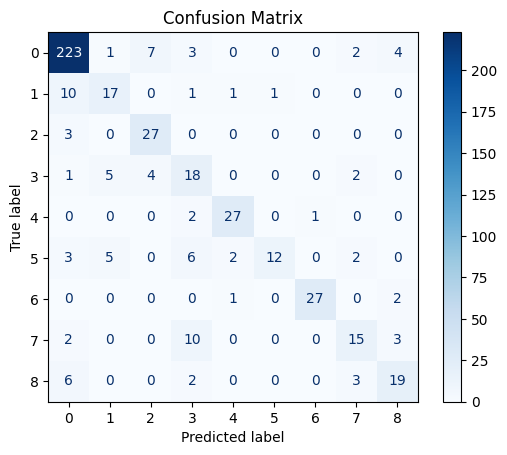

In [58]:
#**** Confusion Matrix ****
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

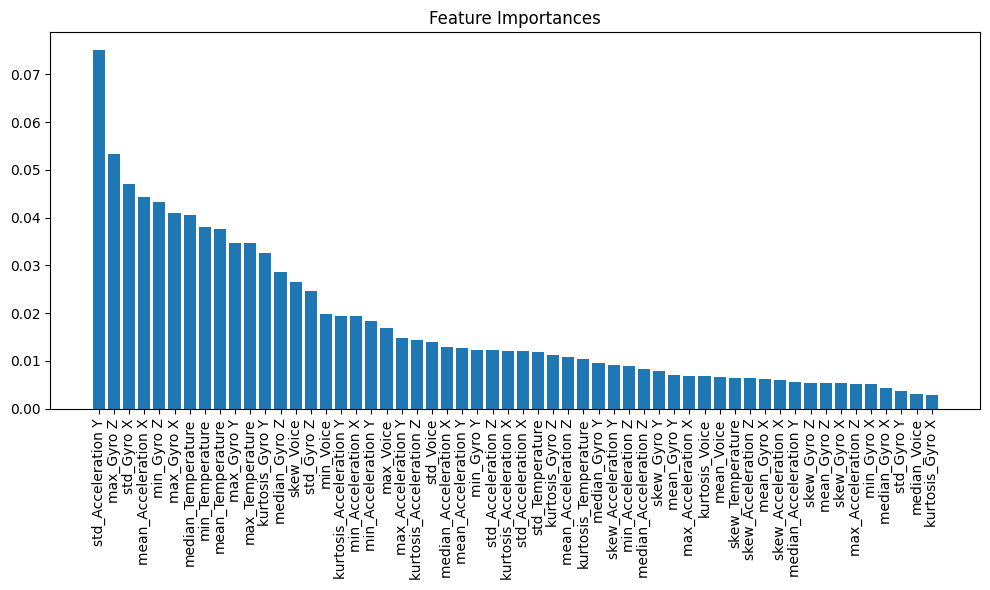

In [59]:
#(classifier)
model = pipeline.named_steps['clf']  # Change 'clf' if your classifier step has a different name

# Feature names from the test set
feature_names = X_test.columns

# Get feature importances from the model
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot feature importances
plt.figure(figsize=(10,6))
plt.title("Feature Importances")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()


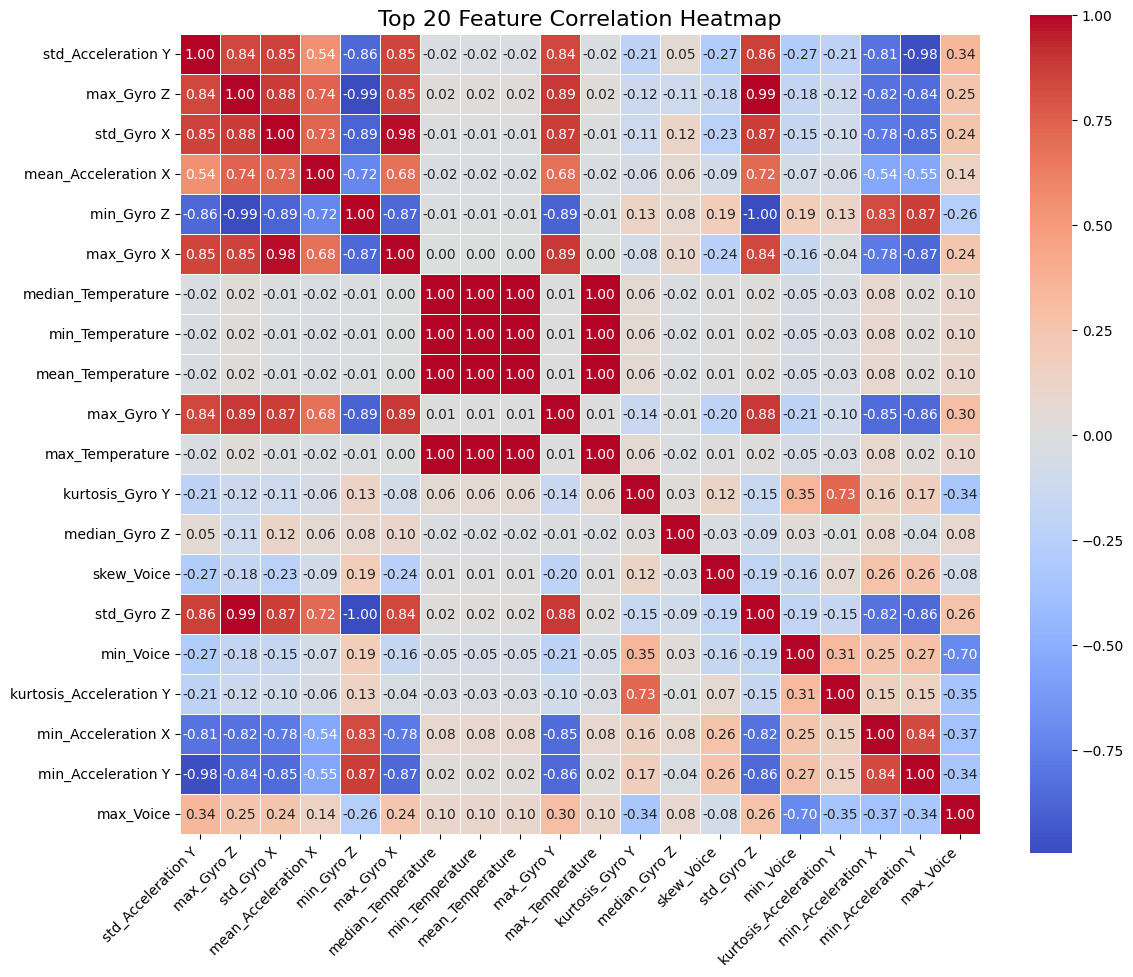

Heatmap of correlations among the top 20 most important features is displayed.


In [60]:
# 1. Select only numeric columns (excluding categorical like label, environment)
numeric_features = X_test.select_dtypes(include=[float, int])

# 2. Take top 20 important features from the model (from previous feature importance)
top_n = 20
top_features = feature_names[indices][:top_n]

# 3. Select data for these top features
top_numeric_features = numeric_features[top_features]

# 4. Compute correlation matrix
corr_matrix_top = top_numeric_features.corr()

# 5. Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix_top, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5, square=True)
plt.title("Top 20 Feature Correlation Heatmap", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Heatmap of correlations among the top 20 most important features is displayed.")

Skipped (no matching columns): test_features.csv
Skipped (no matching columns): test_features_encoded.csv
Skipped (no matching columns): train_features.csv
Skipped (no matching columns): train_features_encoded.csv
Filtered combined CSV saved as 'PM980/combined_filtered.csv'


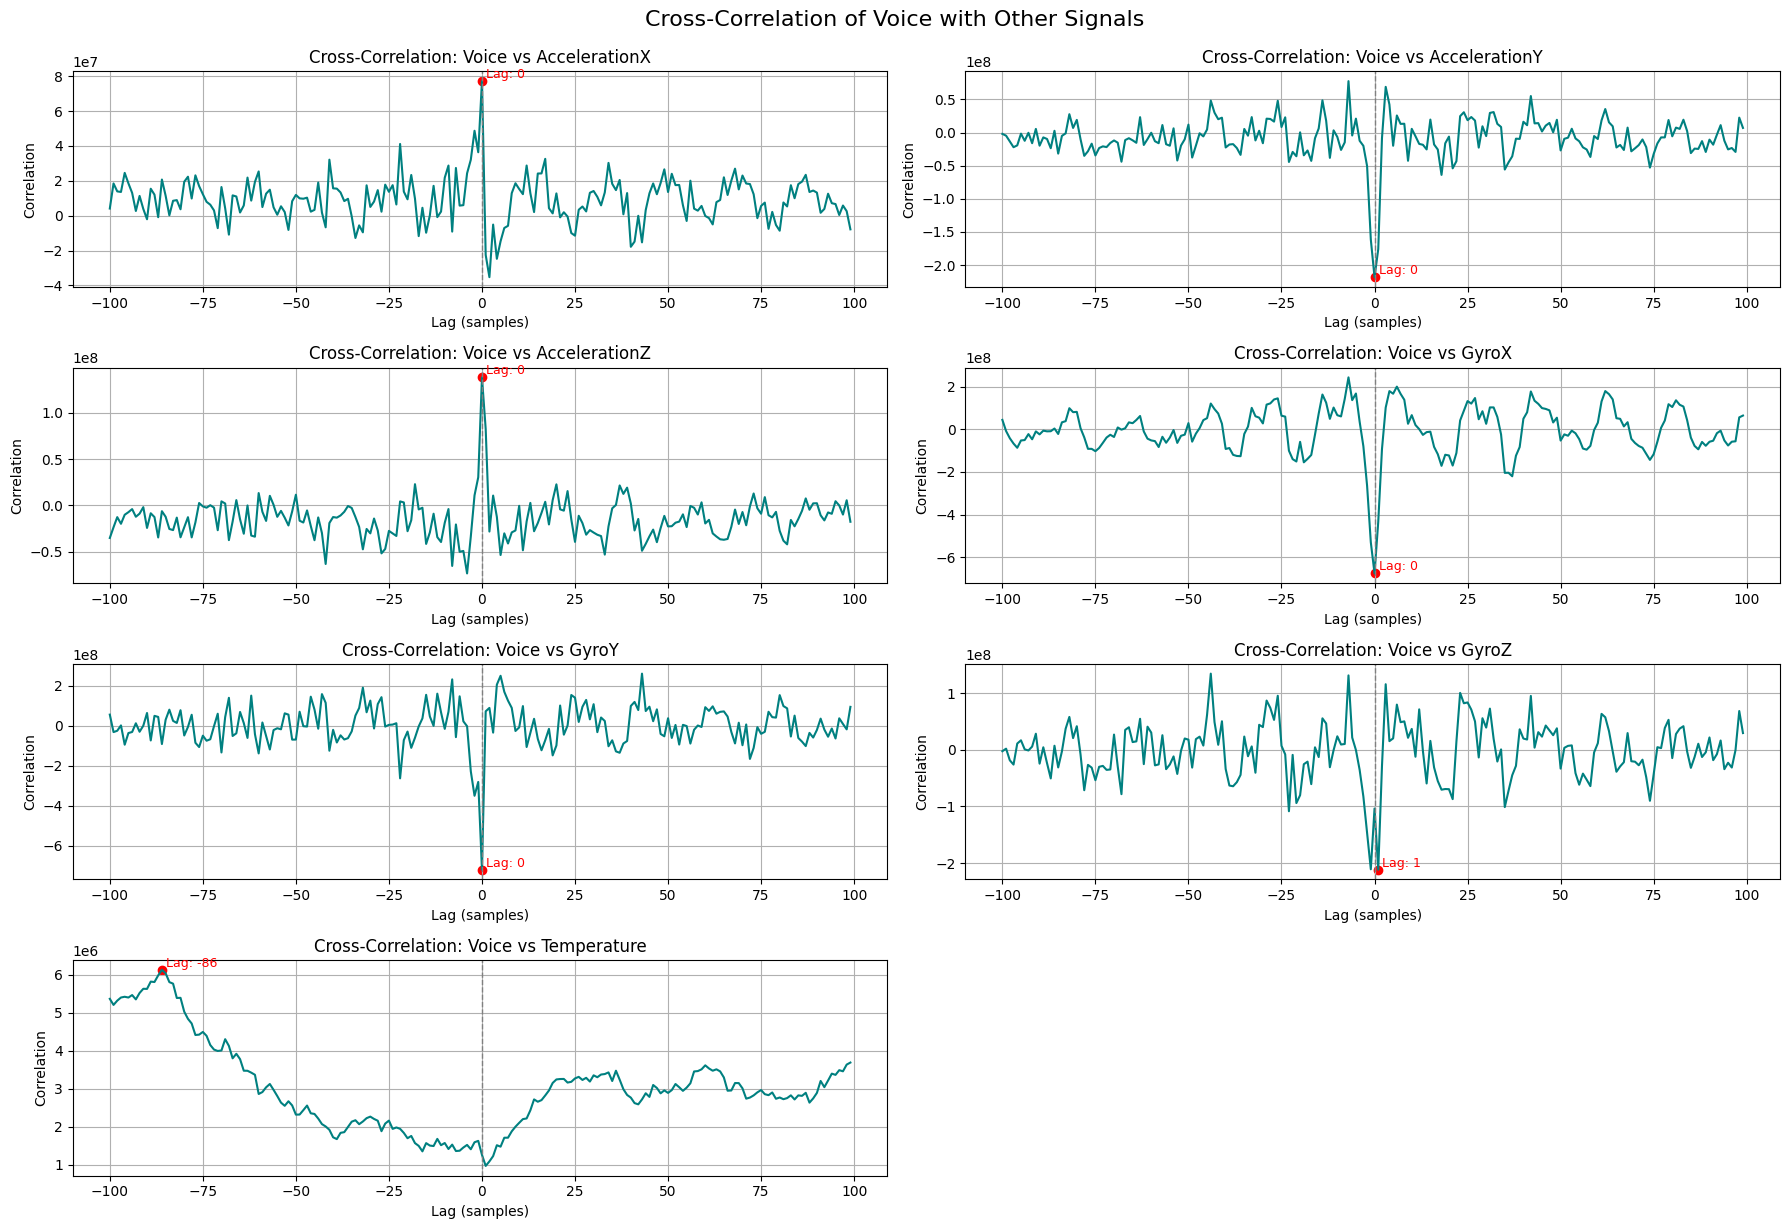

In [61]:
# 1. Folder containing raw CSV files
folder_path = "PM980"
all_data = []

# 2. Desired columns (normalized to match inconsistent naming)
expected_columns = {
    'Voice', 'AccelerationX', 'AccelerationY', 'AccelerationZ',
    'GyroX', 'GyroY', 'GyroZ', 'Temperature'
}

# 3. Read and combine all relevant CSVs
for filename in os.listdir(folder_path):
    if filename.endswith('.csv'):
        file_path = os.path.join(folder_path, filename)
        df = pd.read_csv(file_path)

        # Normalize column names (remove spaces, make lowercase)
        df.columns = df.columns.str.replace(' ', '').str.strip()

        # Select only desired columns if available
        available_columns = list(expected_columns & set(df.columns))

        if available_columns:
            df = df[available_columns]
            all_data.append(df)
        else:
            print(f"Skipped (no matching columns): {filename}")

# 4. Combine all filtered data
combined_df = pd.concat(all_data, ignore_index=True)
combined_df.to_csv("PM980/combined_filtered.csv", index=False)
print("Filtered combined CSV saved as 'PM980/combined_filtered.csv'")

# 5. Load combined data
df = pd.read_csv("PM980/combined_filtered.csv")

# 6. Set base signal for cross-correlation (Voice signal)
base_signal = df['Voice'].values

# 7. Target signals to compare with
targets = ['AccelerationX', 'AccelerationY', 'AccelerationZ', 'GyroX', 'GyroY', 'GyroZ', 'Temperature']
max_lag = 100  # maximum lag to visualize

# 8. Plotting cross-correlations
plt.figure(figsize=(18, 12))

for i, target in enumerate(targets, 1):
    plt.subplot(4, 2, i)
    target_signal = df[target].values

    # Normalize signals before cross-correlation
    corr = correlate(base_signal - np.mean(base_signal), target_signal - np.mean(target_signal), mode='full')
    lags = np.arange(-len(base_signal) + 1, len(base_signal))

    # Extract center portion around zero lag
    center = len(corr) // 2
    corr = corr[center - max_lag:center + max_lag]
    lags = lags[center - max_lag:center + max_lag]

    # Plot with better styling
    plt.plot(lags, corr, color='teal')
    plt.axvline(0, color='gray', linestyle='--', linewidth=1)
    peak_lag = lags[np.argmax(np.abs(corr))]
    peak_val = corr[np.argmax(np.abs(corr))]
    plt.scatter([peak_lag], [peak_val], color='red')
    plt.text(peak_lag, peak_val, f" Lag: {peak_lag}", fontsize=9, ha='left', va='bottom', color='red')

    plt.title(f"Cross-Correlation: Voice vs {target}", fontsize=12)
    plt.xlabel("Lag (samples)")
    plt.ylabel("Correlation")
    plt.grid(True)

plt.tight_layout()
plt.suptitle("Cross-Correlation of Voice with Other Signals", fontsize=16, y=1.02)
plt.show()


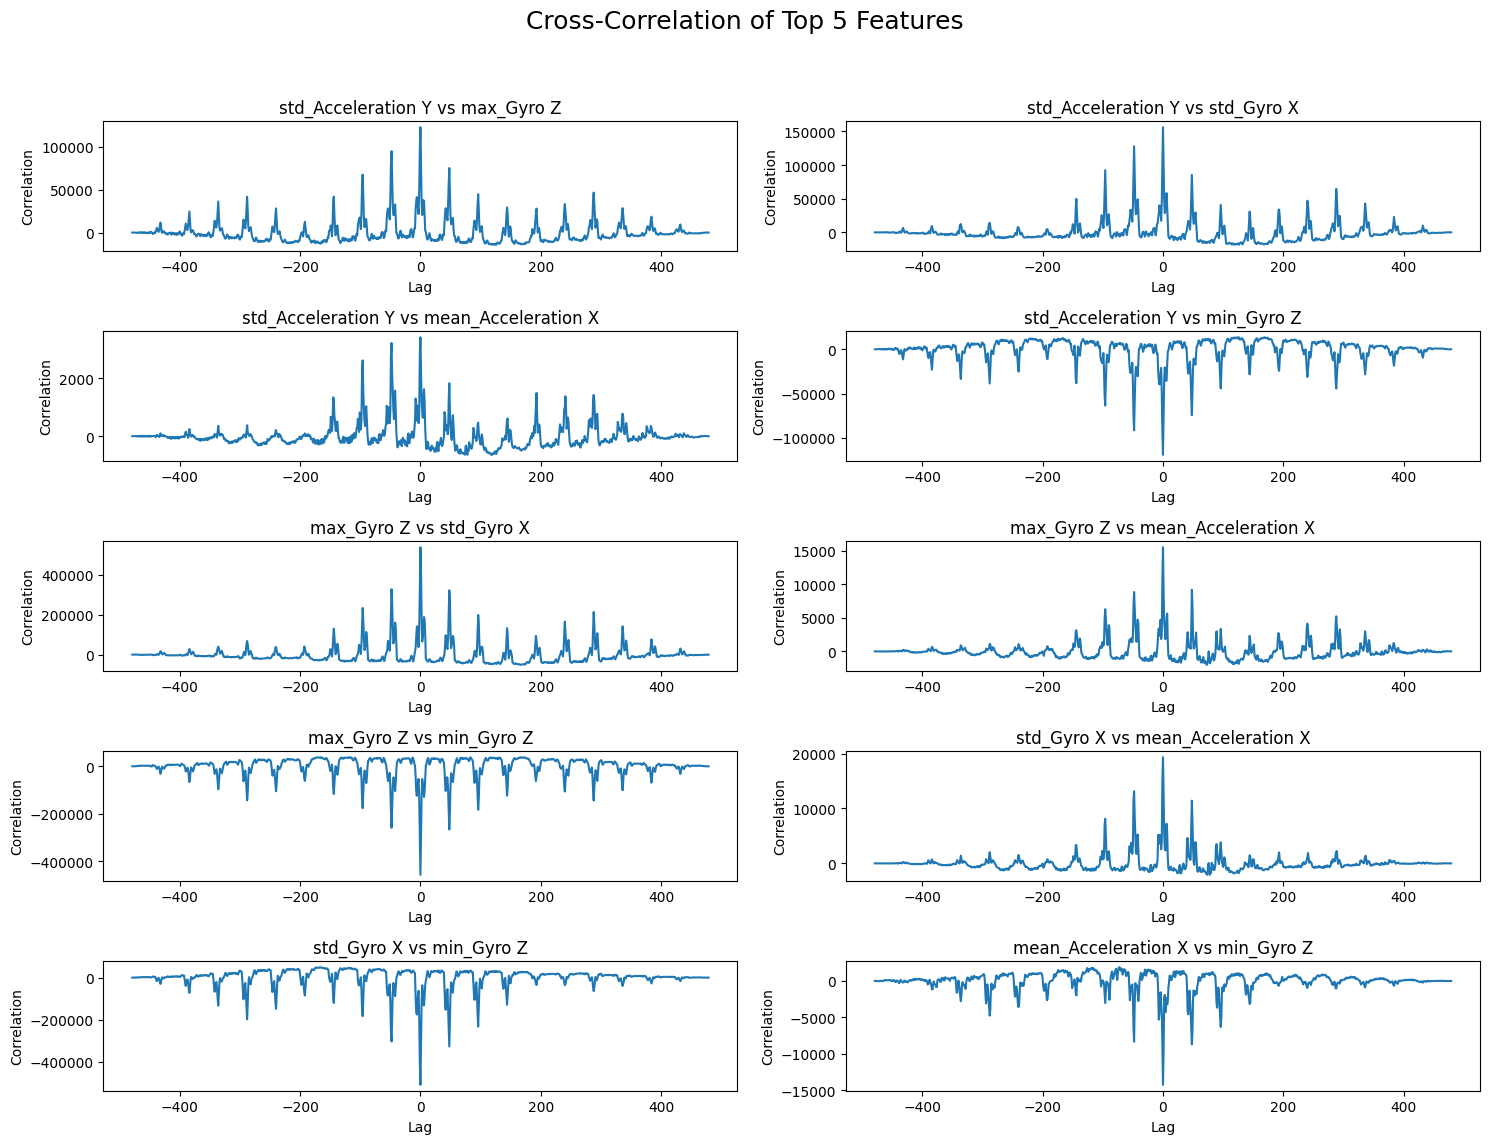

In [67]:
# 1. Get top 5 features from feature importance
top_5_features = feature_names[indices][:5]
plt.figure(figsize=(15, 12))
plot_idx = 1

for i in range(len(top_5_features)):
    for j in range(i+1, len(top_5_features)):
        f1 = top_5_features[i]
        f2 = top_5_features[j]
        
        sig1 = X_test[f1].values
        sig2 = X_test[f2].values
        
        sig1_norm = sig1 - np.mean(sig1)
        sig2_norm = sig2 - np.mean(sig2)
        
        corr = correlate(sig1_norm, sig2_norm, mode='full')
        lags = np.arange(-len(sig1) + 1, len(sig1))
        
        plt.subplot(5, 2, plot_idx)  # 5 satır, 2 sütun = 10 grafik
        plt.plot(lags, corr)
        plt.title(f"{f1} vs {f2}")
        plt.xlabel("Lag")
        plt.ylabel("Correlation")
        plot_idx += 1

plt.suptitle("Cross-Correlation of Top 5 Features", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # başlık üstte kalsın diye
plt.show()


In [136]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


X_train: (384, 56, 1)
X_test: (96, 56, 1)
y_train: (384, 9)
y_test: (96, 9)


In [124]:
# Label encode categorical labels to integers
le = LabelEncoder()
y_enc = le.fit_transform(y)

# One-hot encode labels for classification
y_cat = to_categorical(y_enc)

# Reshape X to 3D for time series models (samples, sequence_length, features)
# Here, sequence_length = 56, features = 1 (frequency points as sequence)
X_3d = np.expand_dims(X, axis=2)

# -------------------------------------------
# 2. Train-Test Split
# -------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_3d, y_cat, test_size=0.2, random_state=42, stratify=y_enc
)

# -------------------------------------------
# 3. Feature Scaling
# -------------------------------------------

# Flatten 3D data to 2D for scaling
nsamples, seq_len, nfeatures = X_train.shape
X_train_reshaped = X_train.reshape(-1, nfeatures)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_reshaped)

# Reshape back to 3D
X_train = X_train_scaled.reshape(nsamples, seq_len, nfeatures)

ntest_samples = X_test.shape[0]
X_test_reshaped = X_test.reshape(-1, nfeatures)
X_test_scaled = scaler.transform(X_test_reshaped)
X_test = X_test_scaled.reshape(ntest_samples, seq_len, nfeatures)

In [126]:
# 4. Model Definitions
# -------------------------------------------

def build_cnn_model(input_shape, num_classes):
    """Builds a 1D CNN model."""
    model = models.Sequential([
        layers.Conv1D(64, 3, activation='relu', input_shape=input_shape),
        layers.Conv1D(64, 3, activation='relu'),
        layers.MaxPooling1D(2),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def build_lstm_model(input_shape, num_classes):
    """Builds an LSTM model."""
    model = models.Sequential([
        layers.LSTM(64, return_sequences=True, input_shape=input_shape),
        layers.LSTM(64),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


In [128]:
# -------------------------------------------
# 5. Model Training and Saving
# -------------------------------------------

In [130]:
input_shape = (seq_len, nfeatures)
num_classes = y_cat.shape[1]

# CNN model training
cnn_model = build_cnn_model(input_shape, num_classes)
cnn_checkpoint = ModelCheckpoint('best_cnn_model.h5', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
earlystop = EarlyStopping(monitor='val_accuracy', patience=5, mode='max', verbose=1)

cnn_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[cnn_checkpoint, earlystop]
)

Epoch 1/30


C:\Users\cav1t\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


 1/12 ━━━━━━━━━━━━━━━━━━━━ 9s 843ms/step - accuracy: 0.0938 - loss: 2.1921
Epoch 1: val_accuracy improved from -inf to 0.50000, saving model to best_cnn_model.h5


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4028 - loss: 1.9771 - val_accuracy: 0.5000 - val_loss: 1.7658
Epoch 2/30
 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5000 - loss: 1.7776
Epoch 2: val_accuracy did not improve from 0.50000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5114 - loss: 1.7245 - val_accuracy: 0.5000 - val_loss: 1.7095
Epoch 3/30
 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3438 - loss: 2.0475
Epoch 3: val_accuracy did not improve from 0.50000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4639 - loss: 1.7868 - val_accuracy: 0.5000 - val_loss: 1.6770
Epoch 4/30
 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4062 - loss: 1.7658
Epoch 4: val_accuracy improved from 0.50000 to 0.51042, saving model to best_cnn_model.h5


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4841 - loss: 1.6870 - val_accuracy: 0.5104 - val_loss: 1.6239
Epoch 5/30
 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4688 - loss: 1.7152
Epoch 5: val_accuracy improved from 0.51042 to 0.52083, saving model to best_cnn_model.h5


...

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5754 - loss: 1.4211 - val_accuracy: 0.5625 - val_loss: 1.4037
Epoch 12/30
 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5938 - loss: 1.2796
Epoch 12: val_accuracy did not improve from 0.56250
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5448 - loss: 1.4235 - val_accuracy: 0.5625 - val_loss: 1.4386
Epoch 13/30
 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5938 - loss: 1.1873
Epoch 13: val_accuracy improved from 0.56250 to 0.58333, saving model to best_cnn_model.h5


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5802 - loss: 1.3516 - val_accuracy: 0.5833 - val_loss: 1.3619
Epoch 14/30
 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3750 - loss: 1.6322
Epoch 14: val_accuracy did not improve from 0.58333
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5321 - loss: 1.4320 - val_accuracy: 0.5729 - val_loss: 1.3440
Epoch 15/30
 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5625 - loss: 1.4549
Epoch 15: val_accuracy did not improve from 0.58333
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5828 - loss: 1.3437 - val_accuracy: 0.5833 - val_loss: 1.3405
Epoch 16/30
 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5625 - loss: 1.3167
Epoch 16: val_accuracy improved from 0.58333 to 0.60417, saving model to best_cnn_model.h5


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5786 - loss: 1.3211 - val_accuracy: 0.6042 - val_loss: 1.3158
Epoch 17/30
 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6250 - loss: 1.3376
Epoch 17: val_accuracy did not improve from 0.60417
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5976 - loss: 1.3238 - val_accuracy: 0.5938 - val_loss: 1.3183
Epoch 18/30
 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5625 - loss: 1.2997
Epoch 18: val_accuracy did not improve from 0.60417
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5809 - loss: 1.3089 - val_accuracy: 0.6042 - val_loss: 1.2970
Epoch 19/30
 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6562 - loss: 1.1253
Epoch 19: val_accuracy improved from 0.60417 to 0.61458, saving model to best_cnn_model.h5


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6024 - loss: 1.2535 - val_accuracy: 0.6146 - val_loss: 1.2927
Epoch 20/30
 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6250 - loss: 1.3389
Epoch 20: val_accuracy improved from 0.61458 to 0.63542, saving model to best_cnn_model.h5


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6059 - loss: 1.2890 - val_accuracy: 0.6354 - val_loss: 1.2918
Epoch 21/30
 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6875 - loss: 1.2177
Epoch 21: val_accuracy did not improve from 0.63542
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6157 - loss: 1.2636 - val_accuracy: 0.6146 - val_loss: 1.2803
Epoch 22/30
 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5312 - loss: 1.3675
Epoch 22: val_accuracy did not improve from 0.63542
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5775 - loss: 1.3032 - val_accuracy: 0.6250 - val_loss: 1.2742
Epoch 23/30
 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5938 - loss: 1.1544
Epoch 23: val_accuracy did not improve from 0.63542
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5827 - loss: 1.2563 - val_accuracy: 0.6146 - val_loss: 1.2571
Epoch 24/30
 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5938 - loss: 1.3313
Epoch 24: val_accuracy did not improve f

In [131]:
# LSTM model training
lstm_model = build_lstm_model(input_shape, num_classes)
lstm_checkpoint = ModelCheckpoint('best_lstm_model.h5', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)

lstm_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[lstm_checkpoint, earlystop]
)


Epoch 1/30


C:\Users\cav1t\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3893 - loss: 2.1456
Epoch 1: val_accuracy improved from -inf to 0.50000, saving model to best_lstm_model.h5


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.4003 - loss: 2.1296 - val_accuracy: 0.5000 - val_loss: 1.7957
Epoch 2/30
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4972 - loss: 1.7930
Epoch 2: val_accuracy did not improve from 0.50000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4976 - loss: 1.7905 - val_accuracy: 0.5000 - val_loss: 1.7575
Epoch 3/30
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5102 - loss: 1.7253
Epoch 3: val_accuracy did not improve from 0.50000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5086 - loss: 1.7290 - val_accuracy: 0.5000 - val_loss: 1.7336
Epoch 4/30
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5182 - loss: 1.6998
Epoch 4: val_accuracy did not improve from 0.50000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5154 - loss: 1.7055 - val_accuracy: 0.5000 - val_loss: 1.7346
Epoch 5/30
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4955 - loss: 1.7420
Epoch 5: val_accuracy did not improve from 

CNN Model Performance:
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Test time: 0.0692 seconds
Accuracy: 0.6354
Precision (macro): 0.4471
Recall (macro): 0.3519
F1-score (macro): 0.3406


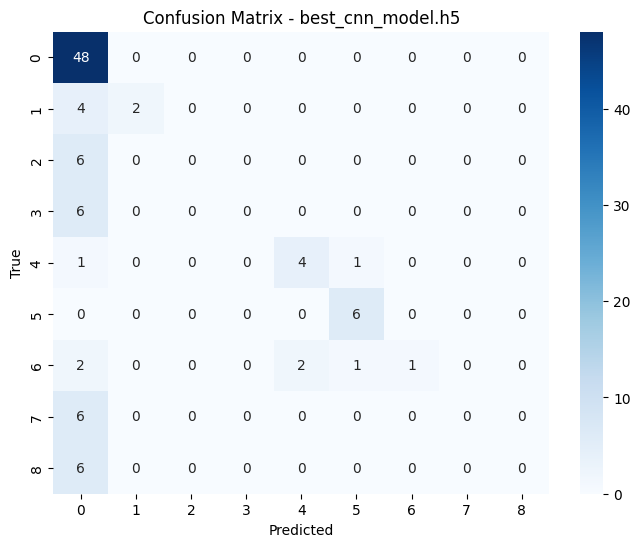

In [142]:
# 6. Model Evaluation
# -------------------------------------------

def evaluate_model(model_path, X_test, y_test):
    """Loads a saved model, evaluates it on test data, prints metrics, and plots confusion matrix."""
    model = tf.keras.models.load_model(model_path)
    
    start_time = time.time()
    y_pred_probs = model.predict(X_test)
    end_time = time.time()

    y_pred_classes = np.argmax(y_pred_probs, axis=1)
    y_true_classes = np.argmax(y_test, axis=1)

    test_time = end_time - start_time
    print(f"Test time: {test_time:.4f} seconds")

    acc = accuracy_score(y_true_classes, y_pred_classes)
    prec = precision_score(y_true_classes, y_pred_classes, average='macro', zero_division=0)
    rec = recall_score(y_true_classes, y_pred_classes, average='macro', zero_division=0)
    f1 = f1_score(y_true_classes, y_pred_classes, average='macro', zero_division=0)

    print(f"Accuracy: {acc:.4f}")
    print(f"Precision (macro): {prec:.4f}")
    print(f"Recall (macro): {rec:.4f}")
    print(f"F1-score (macro): {f1:.4f}")

    cm = confusion_matrix(y_true_classes, y_pred_classes)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix - {model_path}')
    plt.show()

# Evaluate CNN model
print("CNN Model Performance:")
evaluate_model('best_cnn_model.h5', X_test, y_test)


In [144]:
#It was not very accurate for DL ​​because there was not enough test data.